# ══════════════════════════════════════════════════════════════════════
# CELL 1 (Markdown): Title & Research Questions
# ══════════════════════════════════════════════════════════════════════

# 03 — Ad Content Analysis (VLM-Powered)

**Research Questions:**
1. **Source** — Which ad networks dominate each profile's ad stream?
2. **Content** — Does profile seeding shift *what* gets advertised (categories, brands, products)?
3. **Location** — Are ads served in more premium positions to certain profiles?
4. **Tracking** — Do specific ad content types correlate with heavier tracker load?
5. Are observed differentials statistically significant?

**Inputs:** 
- `artifacts/parquet/ads.parquet` (ad metadata from v3.1 capture)
- `artifacts/parquet/ad_desc.parquet` (VLM descriptions from `run_vlm.py`)
- Joined via `ads_enriched` view in `analysis.duckdb`

**Outputs:** `artifacts/figures/03_ad_content/fig10–fig16_*.pdf`

In [12]:
# ══════════════════════════════════════════════════════════════════════
# CELL 2: Setup & Imports
# ══════════════════════════════════════════════════════════════════════
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import DUCKDB_PATH, PROFILE_COLORS, PROFILES
from src.utils.db import get_connection
from src.analysis.ads import (
    vlm_coverage_report,
    ad_counts_by_profile,
    network_distribution_by_profile,
    top_advertiser_networks,
    category_distribution_by_profile,
    top_brands_by_profile,
    top_products_by_profile,
    category_matrix,
    targeting_delta,
    ad_placement_stats,
    iab_size_classification,
    tracking_intensity_by_category,
    tracker_network_cooccurrence,
    network_category_tracking_matrix,
)
from src.viz.ad_plots import (
    apply_style, 
    plot_ad_volume, 
    plot_network_heatmap,
    plot_category_heatmap,
    plot_targeting_delta,
)

apply_style()
FIG_DIR = Path("../artifacts/figures/03_ad_content")
FIG_DIR.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# ══════════════════════════════════════════════════════════════════════
# CELL 3 (Markdown): Section 0 — Data Validation
# ══════════════════════════════════════════════════════════════════════

## Section 0 — VLM Coverage Sanity Check

Before running any downstream analysis, we verify that the VLM has successfully processed a solid majority of captured ads. Rows with `is_valid_ad = NULL` are ads that haven't been through the VLM yet; `is_valid_ad = false` means the VLM flagged the image as non-ad content (e.g., nav element misclassified during capture).

In [13]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4: VLM Coverage Report
# ══════════════════════════════════════════════════════════════════════
coverage = vlm_coverage_report()
print("VLM Processing Coverage:")
display(coverage)

# Compute overall analysis rate
total = coverage['total_ads'].sum()
analyzed = coverage['high_conf'].sum()
print(f"\n📊 {analyzed:,} / {total:,} ads ({100*analyzed/total:.1f}%) "
      f"analyzed at high confidence (≥0.7)")

# Warn if coverage is uneven across profiles (could bias results)
coverage_rate = coverage['high_conf'] / coverage['total_ads']
if coverage_rate.std() > 0.10:
    print("⚠️  Uneven VLM coverage across profiles — results may be biased.")
    print("   Consider re-running run_vlm.py on underserved profiles.")

VLM Processing Coverage:


,profile,total_ads,unprocessed,invalid_ads,high_conf,medium_conf,low_conf,pct_high_conf
0,control,808,0.0,299.0,488.0,21.0,0.0,60.4
1,shopping,798,0.0,309.0,461.0,28.0,0.0,57.8



📊 949.0 / 1,606 ads (59.1%) analyzed at high confidence (≥0.7)


# ══════════════════════════════════════════════════════════════════════
# CELL 5 (Markdown): Section 1 — Ad Volume
# ══════════════════════════════════════════════════════════════════════

## Section 1 — Overall Ad Volume

First-order question: do seeded profiles simply *see more ads*? This is the null-hypothesis baseline — if profiles are treated identically by the ad ecosystem, we'd expect similar volumes.

,profile,n_ads,n_visits,ads_per_visit
0,control,488,500,0.976
1,shopping,461,500,0.922


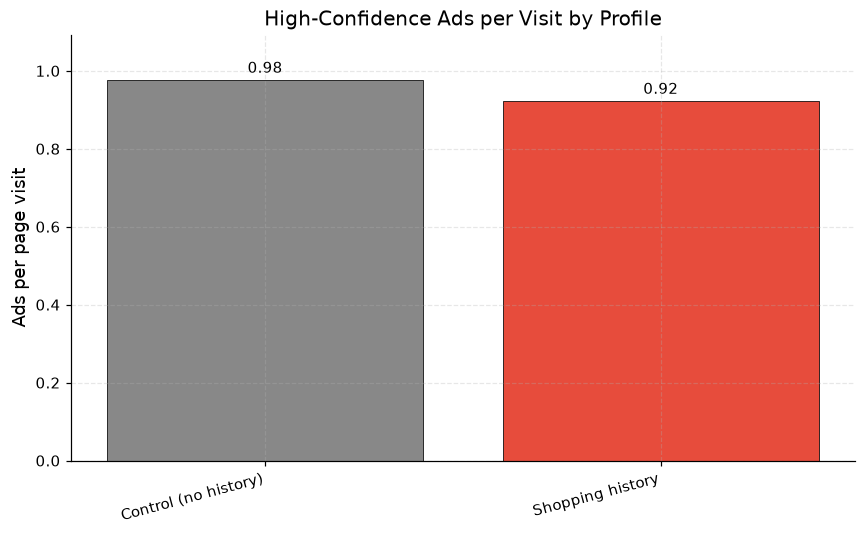

In [14]:
# ══════════════════════════════════════════════════════════════════════
# CELL 6: Ad Volume Analysis
# ══════════════════════════════════════════════════════════════════════
volume = ad_counts_by_profile(min_confidence='high')

# Normalize by visits for a fair per-visit comparison
con = get_connection(read_only=True)
visits = con.execute("""
    SELECT profile, COUNT(*) AS n_visits
    FROM site_visits
    GROUP BY profile
""").df()

volume = volume.merge(visits, on='profile')
volume['ads_per_visit'] = volume['n_ads'] / volume['n_visits']
display(volume)

fig = plot_ad_volume(volume, metric='ads_per_visit',
                     title="High-Confidence Ads per Visit by Profile")
fig.savefig(FIG_DIR / "fig10_ad_volume.pdf", bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════
# CELL 7 (Markdown): Section 2 — Source Analysis
# ══════════════════════════════════════════════════════════════════════

## Section 2 — SOURCE: Which Networks Serve Which Profiles?

Now we look at *who* is placing ads. If certain networks (e.g., Criteo — known for retargeting) show up disproportionately in seeded profiles, that's direct evidence of behavioral targeting infrastructure engaging.

Long-format network distribution (top 20 rows):


,profile,advertiser_network,n_ads,pct
0,control,google_adsense,299,61.27
1,control,gam_slot,117,23.98
2,control,google_doubleclick,46,9.43
3,control,taboola,26,5.33
4,shopping,google_adsense,307,66.59
5,shopping,gam_slot,94,20.39
6,shopping,google_doubleclick,45,9.76
7,shopping,taboola,14,3.04
8,shopping,yahoo,1,0.22



Top 10 Networks — % Share by Profile:


profile,control,shopping
advertiser_network,,
google_adsense,61.3,66.6
gam_slot,24.0,20.4
google_doubleclick,9.4,9.8
taboola,5.3,3.0
yahoo,0.0,0.2


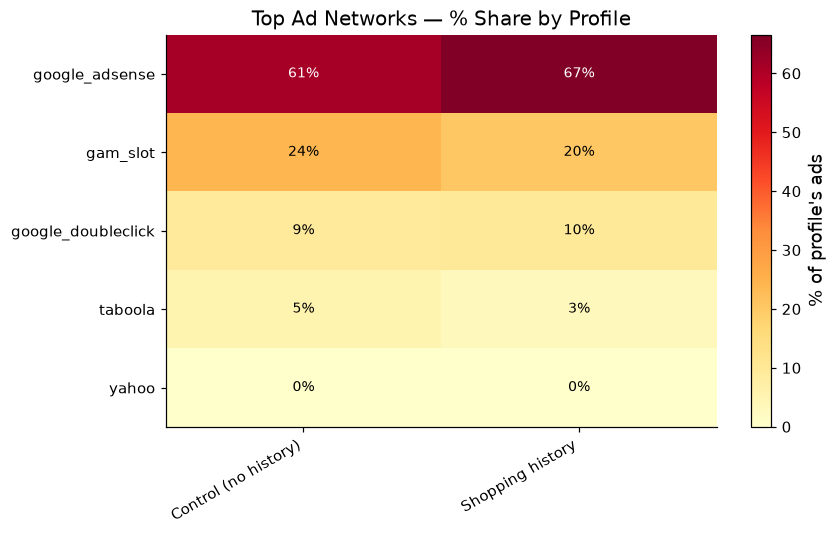

In [15]:
# ══════════════════════════════════════════════════════════════════════
# CELL 8: Network Distribution
# ══════════════════════════════════════════════════════════════════════
network_long = network_distribution_by_profile(min_confidence='high')
print("Long-format network distribution (top 20 rows):")
display(network_long.head(20))

# Heatmap: top 10 networks × profiles
network_pivot = top_advertiser_networks(top_n=10, min_confidence='high')
print("\nTop 10 Networks — % Share by Profile:")
display(network_pivot.round(1))

fig = plot_network_heatmap(network_pivot, 
                           title="Top Ad Networks — % Share by Profile")
fig.savefig(FIG_DIR / "fig11_network_heatmap.pdf", bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════
# CELL 9 (Markdown): Section 3 — Content Analysis (VLM)
# ══════════════════════════════════════════════════════════════════════

## Section 3 — CONTENT: What Is Being Advertised?

This section replaces the old regex/keyword categorization with semantic VLM output. The VLM sees the actual ad image and returns:

- **`category`** — high-level (e.g., "Apparel", "Financial Services")
- **`brand`** — the advertising entity (e.g., "Nike", "Chase")
- **`product`** — specific item (e.g., "Air Max 90", "Sapphire Reserve Card")

The finer the granularity, the stronger the targeting signal.

VLM Category Distribution (top rows):


,profile,category,n_ads,pct_of_profile
0,control,health & wellness,47,9.63
1,control,retail,40,8.20
2,control,education,38,7.79
3,control,automotive,23,4.71
4,control,home & garden,22,4.51
5,control,technology,21,4.30
6,control,consumer electronics,21,4.30
7,control,food & beverage,18,3.69
8,control,finance,17,3.48
9,control,nonprofit & charity,17,3.48



Category × Profile Matrix (% share):


profile,control,shopping
category,,
retail,8.2,14.3
health & wellness,9.6,4.3
home & garden,4.5,8.7
education,7.8,2.2
nonprofit & charity,3.5,6.1
automotive,4.7,4.1
finance,3.5,4.8
entertainment,3.3,4.1
insurance,0.0,7.6


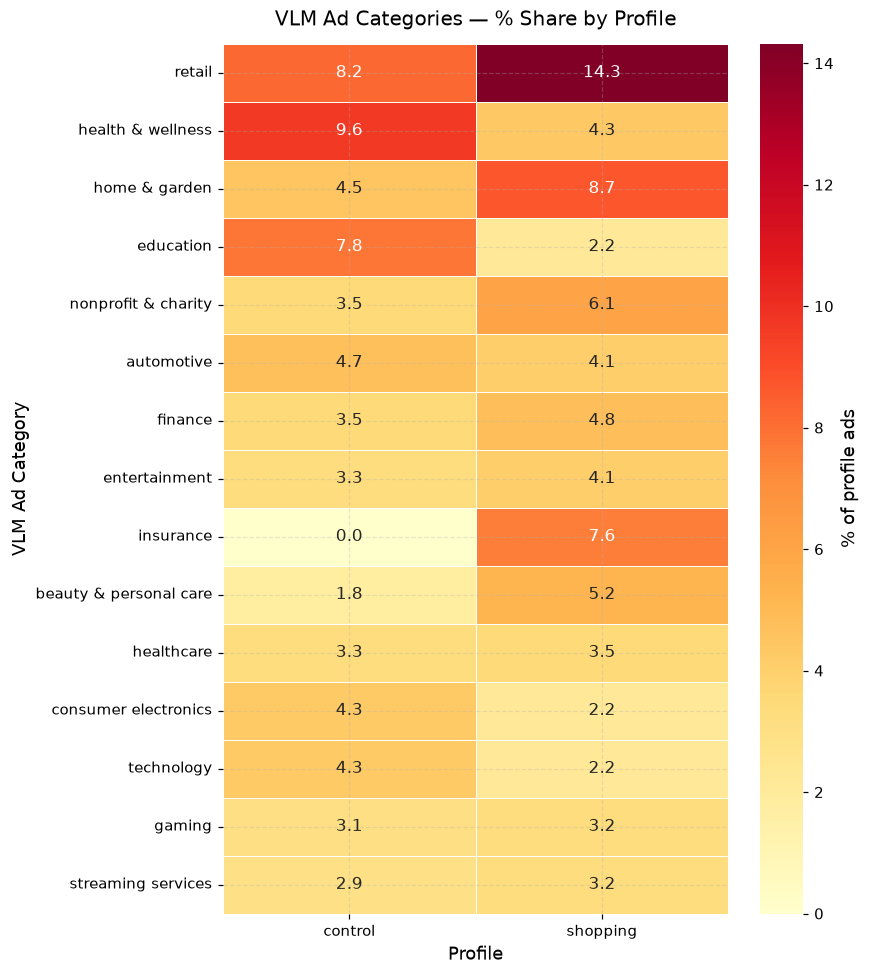

In [16]:
# ══════════════════════════════════════════════════════════════════════
# CELL 10: Category Distribution
# ══════════════════════════════════════════════════════════════════════
categories = category_distribution_by_profile(min_confidence='high', top_n=20)
print("VLM Category Distribution (top rows):")
display(categories.head(30))

# Wide-format matrix for heatmap
cat_matrix = category_matrix(min_confidence='high', top_n=15)
print("\nCategory × Profile Matrix (% share):")
display(cat_matrix.round(1))

fig = plot_category_heatmap(cat_matrix,
                            title="VLM Ad Categories — % Share by Profile")
fig.savefig(FIG_DIR / "fig12_category_heatmap.pdf", bbox_inches='tight')
plt.show()

Category Targeting Delta (shopping − control, in percentage points):


,shopping_minus_control_pct
category,
insurance,7.59
retail,6.12
home & garden,4.17
beauty & personal care,3.37
nonprofit & charity,2.59
finance,1.29
entertainment,0.84
streaming services,0.38
healthcare,0.19


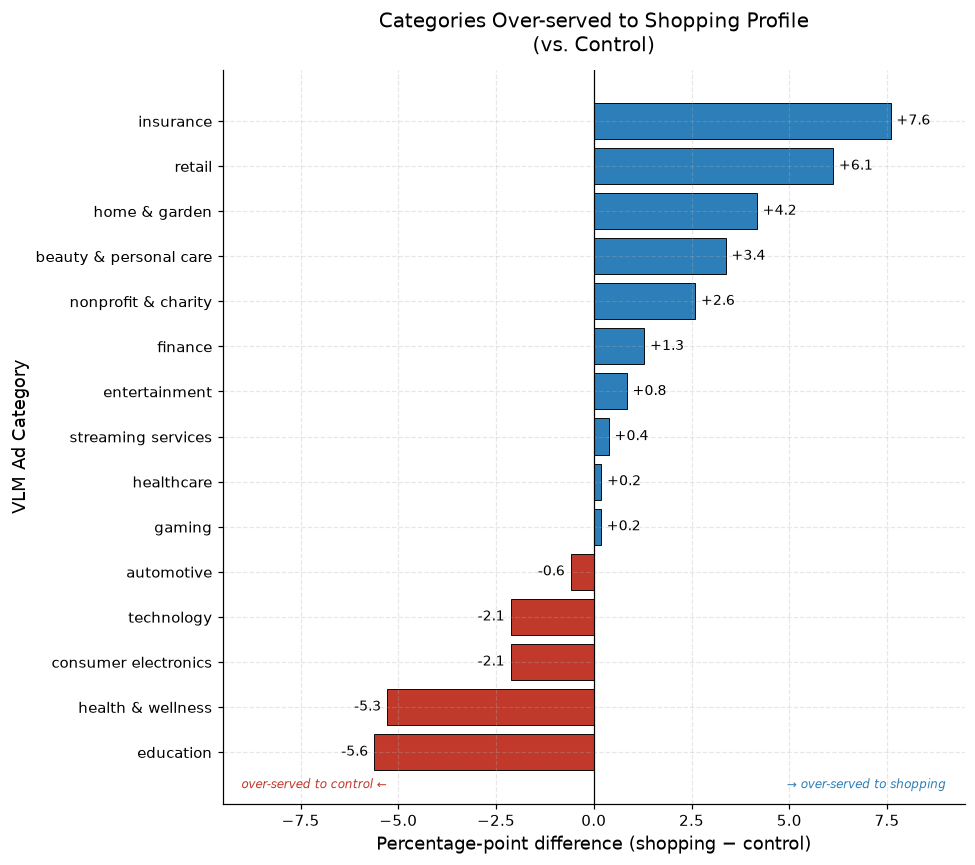

In [17]:
# ══════════════════════════════════════════════════════════════════════
# CELL 11: The "Smoking Gun" — Targeting Delta
# ══════════════════════════════════════════════════════════════════════
delta = targeting_delta(min_confidence='high', top_n=15)
print("Category Targeting Delta (shopping − control, in percentage points):")
display(delta.round(2))

# Save for the paper
delta.to_csv(FIG_DIR / "targeting_delta.csv")

fig = plot_targeting_delta(delta,
                           title="Categories Over-served to Shopping Profile\n"
                                 "(vs. Control)")
fig.savefig(FIG_DIR / "fig13_targeting_delta.pdf", bbox_inches='tight')
plt.show()

In [18]:
# ══════════════════════════════════════════════════════════════════════
# CELL 12: Top Brands & Products
# ══════════════════════════════════════════════════════════════════════
# Brands — the most interpretable evidence
brands = top_brands_by_profile(top_n=15, min_confidence='high')
print("Top Brands by Profile:")
for profile in PROFILES:
    subset = brands[brands['profile'] == profile].head(10)
    print(f"\n── {profile.upper()} ──")
    display(subset[['brand', 'n_ads', 'n_networks', 'modal_confidence']])

# Products — SKU-level retargeting evidence
products = top_products_by_profile(top_n=15, min_confidence='high')
print("\n\nTop Products by Profile:")
for profile in PROFILES:
    subset = products[products['profile'] == profile].head(10)
    print(f"\n── {profile.upper()} ──")
    display(subset[['product', 'n_ads']])

Top Brands by Profile:

── CONTROL ──


,brand,n_ads,n_networks,modal_confidence
0,unknown,96,4,high
1,google,30,3,high
2,aarp,24,2,high
3,midea,8,2,high
4,duke energy,8,2,high
5,amazon,7,2,high
6,disney+,7,2,high
7,newport brass,6,1,high
8,nitto tire,6,1,high
9,aol,6,1,high



── SHOPPING ──


,brand,n_ads,n_networks,modal_confidence
91,unknown,49,5,high
92,1-800-flowers.com,44,3,high
93,aarp,27,3,high
94,progressive,22,2,high
95,1800flowers.com,12,1,high
96,square,11,2,high
97,surfinginsight247.com,10,1,high
98,1-800-flowers,9,3,high
99,ashley,9,2,high
100,bob's discount furniture,8,2,high




Top Products by Profile:

── CONTROL ──


,product,n_ads
0,social security advocacy,24
1,ai training,21
2,package tracking,8
3,credit card,7
4,gutter upgrade,6
5,tires,6
6,banking services,6
7,better search,6
8,insulation upgrade,5
9,news subscription,5



── SHOPPING ──


,product,n_ads
119,flowers,25
120,car insurance,25
121,social security advocacy,21
122,payment processing services,8
123,perfume samples,7
124,checking account,6
125,tires,6
126,donations to disaster relief efforts,5
127,furniture,5
128,continuous glucose monitor (cgm),5


# ══════════════════════════════════════════════════════════════════════
# CELL 13 (Markdown): Section 4 — Location Analysis
# ══════════════════════════════════════════════════════════════════════

## Section 4 — LOCATION: Where on the Page Do Ads Appear?

Premium ad positions (above the fold, large formats like leaderboards) command higher CPMs. A profile receiving more premium placements is being *valued* more highly by the ad ecosystem — an indirect measure of profile richness.

Ad Placement Statistics by Profile:


,profile,n_ads,avg_x,avg_y,avg_width,avg_height,avg_area,above_fold_count,pct_above_fold
0,control,488,426.3,3845.8,669.0,248.7,154859.1,120.0,24.59
1,shopping,461,439.2,3253.2,642.8,259.4,146319.7,138.0,29.93


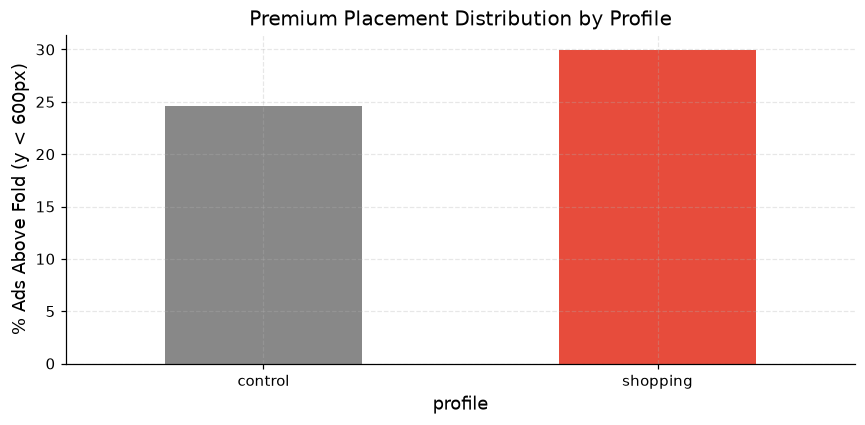

In [19]:
# ══════════════════════════════════════════════════════════════════════
# CELL 14: Ad Placement Stats
# ══════════════════════════════════════════════════════════════════════
placement = ad_placement_stats(min_confidence='high')
print("Ad Placement Statistics by Profile:")
display(placement)

# Visualize above-fold percentage
fig, ax = plt.subplots(figsize=(8, 4))
placement.plot(x='profile', y='pct_above_fold', kind='bar', 
               ax=ax, color=[PROFILE_COLORS.get(p, '#888') for p in placement['profile']],
               legend=False)
ax.set_ylabel("% Ads Above Fold (y < 600px)")
ax.set_title("Premium Placement Distribution by Profile")
ax.set_xticklabels(placement['profile'], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig14_placement.pdf", bbox_inches='tight')
plt.show()

IAB Standard Size Distribution:


profile,control,shopping
iab_size,,
160x600 skyscraper,1.6,2.4
300x250 medium rect,18.6,17.8
300x600 half-page,1.6,4.8
320x50 mobile banner,1.2,0.2
728x90 leaderboard,12.1,11.9
970x250 billboard,7.4,7.2
large (>500x500),13.9,11.7
non-standard,43.4,44.0


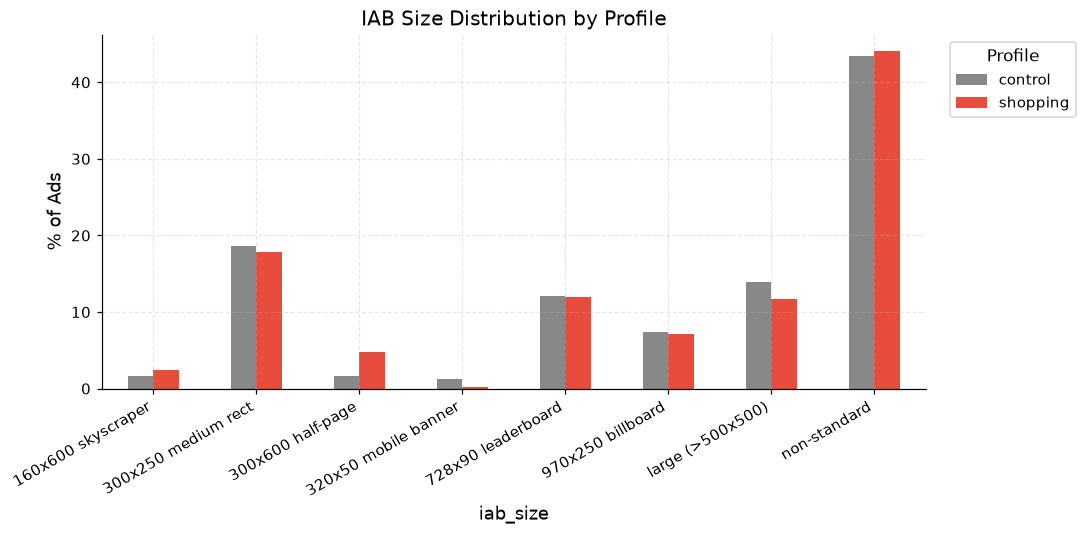

In [20]:
# ══════════════════════════════════════════════════════════════════════
# CELL 15: IAB Standard Size Distribution
# ══════════════════════════════════════════════════════════════════════
iab = iab_size_classification(min_confidence='high')
print("IAB Standard Size Distribution:")

iab_pivot = iab.pivot(index='iab_size', columns='profile', 
                     values='n_ads').fillna(0)
# Convert to % share
iab_pct = iab_pivot.div(iab_pivot.sum(axis=0), axis=1) * 100
display(iab_pct.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
iab_pct.plot(kind='bar', ax=ax,
             color=[PROFILE_COLORS.get(p, '#888') for p in iab_pct.columns])
ax.set_ylabel("% of Ads")
ax.set_title("IAB Size Distribution by Profile")
ax.legend(title="Profile", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / "fig15_iab_sizes.pdf", bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════
# CELL 16 (Markdown): Section 5 — Tracking Correlation
# ══════════════════════════════════════════════════════════════════════

## Section 5 — TRACKING: Content ↔ Tracker Co-occurrence

The most integrative view: does the *type* of ad on a page predict how heavily that page tracks the user? This bridges the ad content analysis (this notebook) with the tracker analysis (notebook 02).

In [21]:
# ══════════════════════════════════════════════════════════════════════
# CELL 17: Tracking Intensity by Category
# ══════════════════════════════════════════════════════════════════════
tracking = tracking_intensity_by_category(min_confidence='high')
print("Avg. Tracker Count on Pages by VLM Ad Category:")
display(tracking.head(25))

# Top-5 highest tracking categories
top_tracked = (tracking.groupby('category')['avg_trackers_on_page']
               .mean().nlargest(10))
print("\n🎯 Top 10 Ad Categories by Avg. Tracker Load:")
display(top_tracked.round(1).to_frame("avg_trackers"))

BinderException: Binder Error: Referenced column "is_tracker" not found in FROM clause!
Candidate bindings: "is_third_party_channel", "is_third_party_to_top_window", "is_XHR", "time_stamp", "frame_ancestors"

LINE 5:                 WHERE is_tracker = true
                              ^

In [ ]:


# ══════════════════════════════════════════════════════════════════════
# CELL 18: Network × Tracker Co-occurrence
# ══════════════════════════════════════════════════════════════════════
cooccur = tracker_network_cooccurrence(min_confidence='high', top_n=25)
print("Ad Networks ↔ Tracker Domains Co-occurrence:")
display(cooccur)

cooccur.to_csv(FIG_DIR / "network_tracker_cooccurrence.csv", index=False)

BinderException: Binder Error: Values list "hr" does not have a column named "is_tracker"

LINE 10:               AND hr.is_tracker = true
                           ^

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 19: Three-Way Matrix (Network × Category × Tracking)
# ══════════════════════════════════════════════════════════════════════
three_way = network_category_tracking_matrix(min_confidence='high')
print("The Smoking Gun Table — (Network × Category × Avg. Trackers):")
display(three_way.head(30))

# Filter to shopping profile only for the paper's headline table
shopping_smoking_gun = (three_way[three_way['profile'] == 'shopping']
                        .sort_values('avg_trackers', ascending=False)
                        .head(15))
print("\nTop 15 (Network, Category) Combinations for Shopping Profile:")
display(shopping_smoking_gun)
shopping_smoking_gun.to_csv(FIG_DIR / "shopping_smoking_gun.csv", index=False)

BinderException: Binder Error: Referenced column "is_tracker" not found in FROM clause!
Candidate bindings: "is_third_party_channel", "is_third_party_to_top_window", "is_XHR", "time_stamp", "frame_ancestors"

LINE 5:                 WHERE is_tracker = true
                              ^

# ══════════════════════════════════════════════════════════════════════
# CELL 20 (Markdown): Section 6 — Statistical Significance
# ══════════════════════════════════════════════════════════════════════

## Section 6 — Statistical Significance

Delta values are only meaningful if they exceed what we'd expect by chance. We run:

1. **Chi-square test** on the full category × profile contingency table (omnibus)
2. **Per-category Fisher's exact** with Benjamini-Hochberg correction (pinpoint)

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 21: Chi-Square Omnibus Test
# ══════════════════════════════════════════════════════════════════════
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# Build contingency: rows=categories, cols=profiles, values=raw counts
contingency = con.execute("""
    SELECT 
        LOWER(TRIM(category)) AS category,
        profile,
        COUNT(*) AS n_ads
    FROM ads_enriched
    WHERE is_valid_ad = true 
      AND confidence = 'high'
      AND category IS NOT NULL
    GROUP BY LOWER(TRIM(category)), profile
""").df().pivot(index='category', columns='profile', 
                values='n_ads').fillna(0).astype(int)

# Filter to categories with ≥10 total ads (avoid sparse cells)
contingency = contingency[contingency.sum(axis=1) >= 10]
print(f"Contingency table shape: {contingency.shape}")
display(contingency.head(10))

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\n🔬 Chi-square omnibus test:")
print(f"   χ² = {chi2:.2f}, dof = {dof}, p = {p_value:.2e}")
print(f"   {'✅ SIGNIFICANT' if p_value < 0.05 else '❌ Not significant'} "
      f"at α = 0.05")

NameError: name 'con' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 22: Per-Category Fisher's Exact + FDR Correction
# ══════════════════════════════════════════════════════════════════════
if 'shopping' in contingency.columns and 'control' in contingency.columns:
    total_shopping = contingency['shopping'].sum()
    total_control = contingency['control'].sum()
    
    results = []
    for cat in contingency.index:
        s_cat = contingency.loc[cat, 'shopping']
        c_cat = contingency.loc[cat, 'control']
        table = [[s_cat, total_shopping - s_cat],
                 [c_cat, total_control - c_cat]]
        odds_ratio, p = fisher_exact(table)
        results.append({'category': cat,
                        'shopping_n': s_cat,
                        'control_n': c_cat,
                        'odds_ratio': odds_ratio,
                        'p_value': p})
    
    fisher_df = pd.DataFrame(results)
    # BH correction for multiple testing
    _, p_adj, _, _ = multipletests(fisher_df['p_value'], 
                                    method='fdr_bh')
    fisher_df['p_adj_bh'] = p_adj
    fisher_df['significant'] = fisher_df['p_adj_bh'] < 0.05
    fisher_df = fisher_df.sort_values('p_adj_bh')
    
    print("Per-Category Fisher's Exact (BH-corrected):")
    display(fisher_df.round(4))
    
    sig_cats = fisher_df[fisher_df['significant']]['category'].tolist()
    print(f"\n📌 {len(sig_cats)} categories significantly different "
          f"between shopping and control after FDR correction.")
    
    fisher_df.to_csv(FIG_DIR / "category_significance.csv", index=False)

NameError: name 'contingency' is not defined

# ══════════════════════════════════════════════════════════════════════
# CELL 23 (Markdown): Section 7 — Summary for Paper
# ══════════════════════════════════════════════════════════════════════

## Section 7 — Summary for Paper

**Key findings to highlight:**

1. **Volume** (Cell 6) — Are seeded profiles seeing more ads per visit?
2. **Sources** (Cell 8) — Which ad networks over-index in seeded profiles?
3. **Content shift** (Cell 11) — Categories with the largest shopping−control delta
4. **Brand/product evidence** (Cell 12) — Direct retargeting fingerprints
5. **Placement premium** (Cell 14–15) — Is seeded profile "worth more" to the ecosystem?
6. **Tracking correlation** (Cell 19) — The (Network, Category) combinations that trigger the heaviest tracking — this is your headline finding
7. **Statistical rigor** (Cells 21–22) — Chi-square + FDR-corrected per-category tests

**Files saved to `artifacts/figures/03_ad_content/`:**
- `fig10_ad_volume.pdf`
- `fig11_network_heatmap.pdf`
- `fig12_category_heatmap.pdf`
- `fig13_targeting_delta.pdf`
- `fig14_placement.pdf`
- `fig15_iab_sizes.pdf`
- `targeting_delta.csv`
- `network_tracker_cooccurrence.csv`
- `shopping_smoking_gun.csv`
- `category_significance.csv`